# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('NY-House-Dataset.csv')
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [4]:
df.columns

Index(['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
       'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
       'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE'],
      dtype='object')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

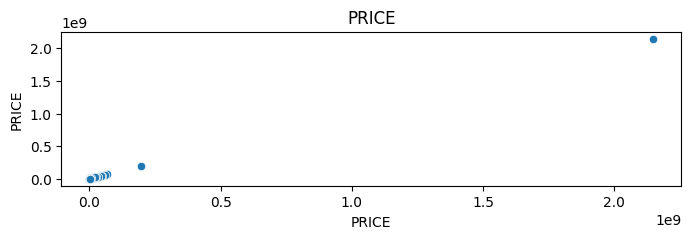

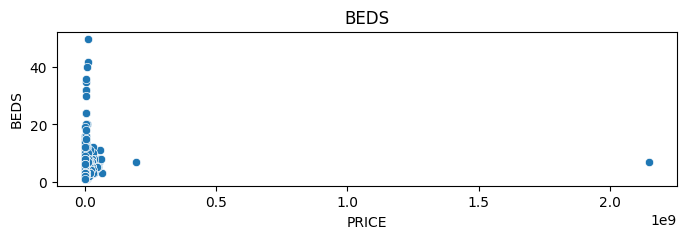

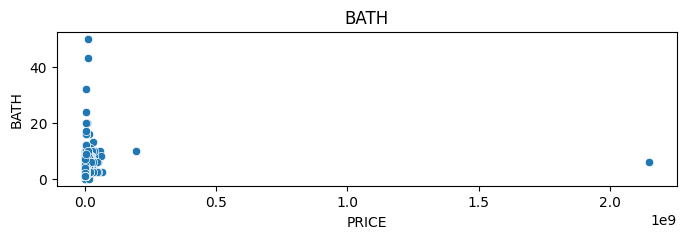

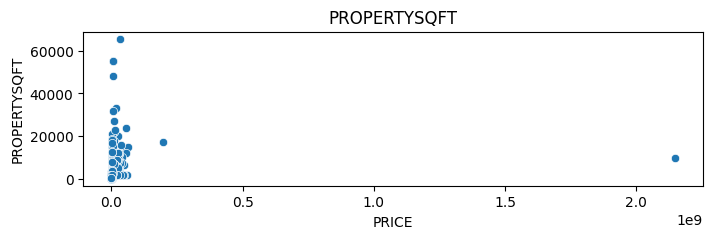

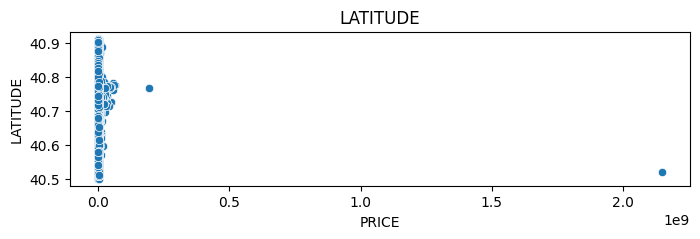

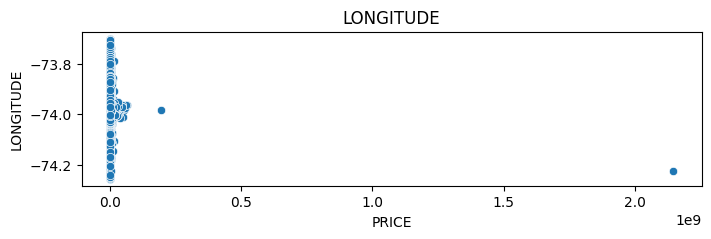

In [5]:
num_cols_boxplot = ["PRICE","BEDS","BATH","PROPERTYSQFT","LATITUDE","LONGITUDE"]

for col in num_cols_boxplot:
    plt.figure(figsize=(8,2))
    sns.scatterplot(x=df['PRICE'], y=df[col])
    plt.title(col)
    plt.show()

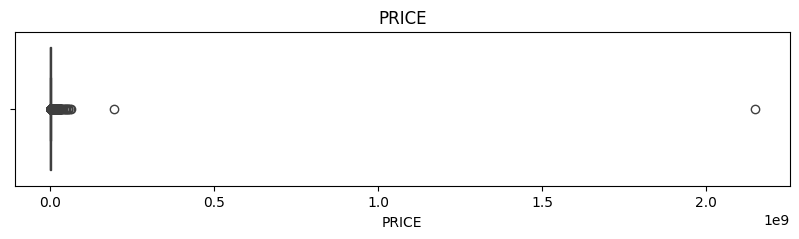

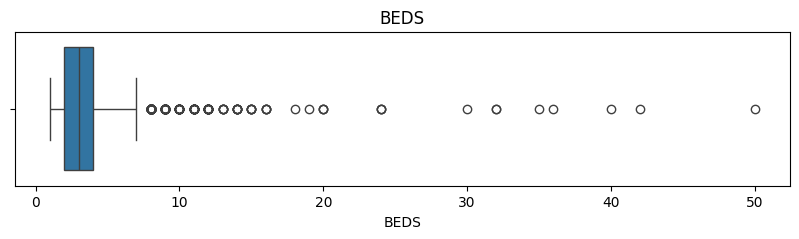

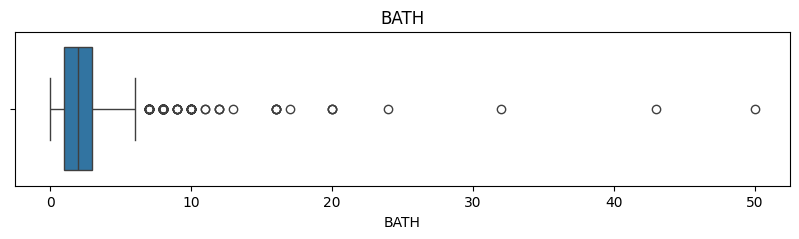

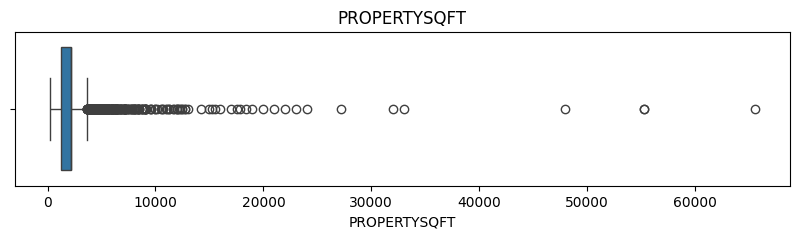

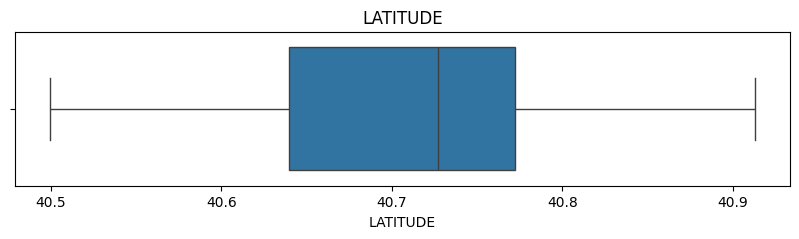

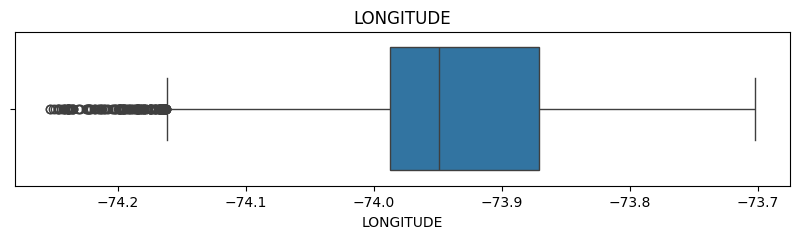

In [6]:
num_cols_boxplot = ["PRICE","BEDS","BATH","PROPERTYSQFT","LATITUDE","LONGITUDE"]

for col in num_cols_boxplot:
    plt.figure(figsize=(10,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

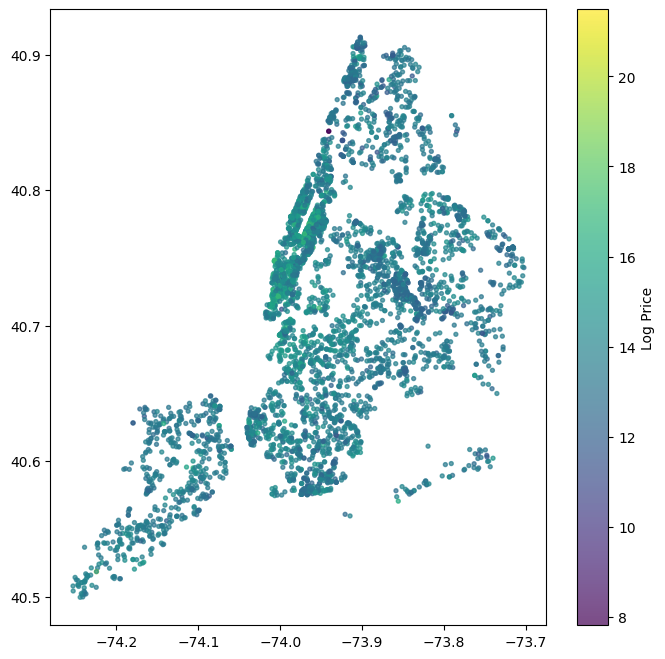

In [7]:
plt.figure(figsize=(8,8))

plt.scatter(
    df["LONGITUDE"],
    df["LATITUDE"],
    c=np.log1p(df["PRICE"]),
    s=8,
    alpha=0.7
)

plt.colorbar(label="Log Price")

<Axes: >

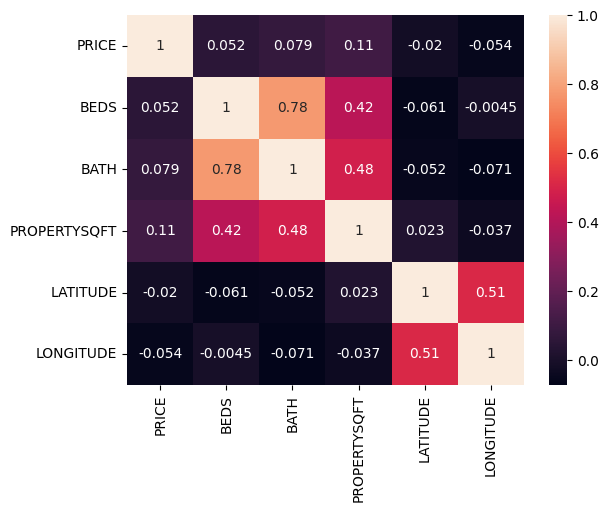

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [9]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

BROKERTITLE: 1036
TYPE: 13
PRICE: 1274
BEDS: 27
BATH: 22
PROPERTYSQFT: 1445
ADDRESS: 4582
STATE: 308
MAIN_ADDRESS: 4583
ADMINISTRATIVE_AREA_LEVEL_2: 29
LOCALITY: 11
SUBLOCALITY: 21
STREET_NAME: 174
LONG_NAME: 2731
FORMATTED_ADDRESS: 4550
LATITUDE: 4196
LONGITUDE: 4118


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
cols_to_drop = [
    "BROKERTITLE",
    "ADDRESS",
    "MAIN_ADDRESS",
    "LONG_NAME",
    "STATE",
    "FORMATTED_ADDRESS",
]

df = df.drop(columns=cols_to_drop)

duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(
    by=df.columns.tolist()
)

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LATITUDE,LONGITUDE
3412,Co-op for sale,99000,1,1.0,850.000000,New York,Bronx County,The Bronx,Highbridge,40.836662,-73.923959
3415,Co-op for sale,99000,1,1.0,850.000000,New York,Bronx County,The Bronx,Highbridge,40.836662,-73.923959
3615,Co-op for sale,119000,3,1.0,2184.207862,New York,Queens County,Queens,Jamaica,40.709570,-73.791130
3625,Co-op for sale,119000,3,1.0,2184.207862,New York,Queens County,Queens,Jamaica,40.709570,-73.791130
1400,Co-op for sale,129000,3,1.0,2184.207862,New York,Queens County,Queens,Jamaica,40.710451,-73.798206
...,...,...,...,...,...,...,...,...,...,...,...
279,Townhouse for sale,2649000,5,4.0,4050.000000,United States,New York,Kings County,Brooklyn,40.682092,-73.939392
1342,Townhouse for sale,23000000,5,6.0,7058.000000,United States,New York,New York County,New York,40.743919,-74.001436
1349,Townhouse for sale,23000000,5,6.0,7058.000000,United States,New York,New York County,New York,40.743919,-74.001436
3073,Townhouse for sale,24950000,7,5.0,12000.000000,United States,New York,New York County,New York,40.770069,-73.967933


In [11]:
print(df.shape)
df = df.drop_duplicates()
print(df.shape)

(4801, 11)
(4586, 11)


In [12]:
NUMERIC_FEATURES = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "LATITUDE",
    "LONGITUDE",
]

CATEGORICAL_FEATURES = [
    "TYPE",
    "LOCALITY",
    "SUBLOCALITY",
    "ADMINISTRATIVE_AREA_LEVEL_2",
]

def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                StandardScaler(),
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                CATEGORICAL_FEATURES,
            ),
        ]
    )

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.reset_index(drop=True)

    X = df.drop(columns=["PRICE"])
    y = df["PRICE"]

    preprocessor = build_preprocessor()
    X_processed = preprocessor.fit_transform(X)

    feature_names = preprocessor.get_feature_names_out()

    X_processed = pd.DataFrame(
        X_processed,
        columns=feature_names,
    )
    processed_df = pd.concat(
        [
            X_processed,
            y,
        ],
        axis=1,
    )
    return processed_df

processed_df = preprocess(df)
processed_df.to_csv(
    "ny_house_preprocessing.csv",
    index=False,
)